# Unit13_Example_06 | 化工案例四：加熱程序動態響應之轉移函數參數估計

本 Notebook 以加熱程序之 **二階加時間延遲（SOPDT）** 動態模式為題，使用 `scipy.optimize.curve_fit()` 進行非線性最小平方參數估計，並計算各參數之 95% 置信區間。

## 目標
- 由 SOPDT 轉移函數 $G(s) = K_p e^{-t_d s} / [(\tau_1 s+1)(\tau_2 s+1)]$ 推導階梯響應時域解析式
- 使用 `curve_fit(method='trf')` 估計四個參數 $K_p, \tau_1, \tau_2, t_d$
- 由協方差矩陣 `pcov` 推算 95% 置信區間
- 繪製程序響應擬合圖與殘差分析圖

## 大綱
0. 環境設定
1. 載入套件
2. 問題描述與實驗數據
3. 轉移函數模式定義（時域解析式）
4. 參數估計與置信區間（`curve_fit`）
5. 各量測點驗證
6. 結果視覺化

---
### 0. 環境設定

In [9]:
from pathlib import Path
import os

# ========================================
# 路徑設定 (兼容 Colab 與 Local)
# ========================================
UNIT_OUTPUT_DIR = 'Unit13_Example_06'

try:
    from google.colab import drive
    IN_COLAB = True
    print("✓ 偵測到 Colab 環境，準備掛載 Google Drive...")
    drive.mount('/content/drive', force_remount=True)
except ImportError:
    IN_COLAB = False
    print("✓ 偵測到 Local 環境")

try:
    shortcut_path = '/content/ChemE-3502'
    os.remove(shortcut_path)
except (FileNotFoundError, OSError):
    pass

if IN_COLAB:
    source_path = Path('/content/drive/My Drive/Colab Notebooks/ChemE-3502')
    os.symlink(source_path, shortcut_path)
    shortcut_path = Path(shortcut_path)
    if source_path.exists():
        NOTEBOOK_DIR = shortcut_path / 'Unit13'
        OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
        FIG_DIR      = OUTPUT_DIR / 'figs'
    else:
        print("⚠️ 找不到雲端 ChemE-3502 路徑，請確認資料夾名稱是否正確")
else:
    NOTEBOOK_DIR = Path.cwd()
    OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
    FIG_DIR      = OUTPUT_DIR / 'figs'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Notebook工作目錄: {NOTEBOOK_DIR}")
print(f"✓ 結果輸出目錄: {OUTPUT_DIR}")
print(f"✓ 圖檔輸出目錄: {FIG_DIR}")

✓ 偵測到 Local 環境

✓ Notebook工作目錄: d:\MyGit\ChemE-3502\Unit13
✓ 結果輸出目錄: d:\MyGit\ChemE-3502\Unit13\outputs\Unit13_Example_06
✓ 圖檔輸出目錄: d:\MyGit\ChemE-3502\Unit13\outputs\Unit13_Example_06\figs


---
### 1. 載入套件

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import curve_fit
from scipy.stats import t as t_dist

# ── Matplotlib 全域設定 ──────────────────────────────
plt.rcParams.update({
    'font.family'       : 'DejaVu Sans',
    'font.size'         : 12,
    'axes.titlesize'    : 13,
    'axes.labelsize'    : 12,
    'legend.fontsize'   : 11,
    'figure.dpi'        : 100,
    'axes.unicode_minus': False,
})

# ── 版本確認 ─────────────────────────────────────────
print(f"NumPy   : {np.__version__}")
import scipy; print(f"SciPy   : {scipy.__version__}")
import matplotlib; print(f"Matplotlib: {matplotlib.__version__}")

NumPy   : 1.23.5
SciPy   : 1.15.2
Matplotlib: 3.10.8


---
### 2. 問題描述與實驗數據

一加熱程序在穩態操作下，對流量施加一步階輸入 $\Delta Q = 0.7 \text{ m}^3/\text{min}$ ，量測16個時間點之溫度偏差響應。

假設系統以**二階加純時延（SOPDT）轉移函數**描述：

$$
G(s) = \frac{K_p \, e^{-t_d s}}{(\tau_1 s + 1)(\tau_2 s + 1)}
$$

純時延項的時域解析式為：

$$
\Delta T(t) = K_p \cdot \Delta Q \left[1 - \frac{\tau_1 e^{-(t-t_d)/\tau_1} - \tau_2 e^{-(t-t_d)/\tau_2}}{\tau_1 - \tau_2}\right] u(t - t_d)
$$

其中 $u(\cdot)$ 為單位步階函數。待估計參數為 $\boldsymbol{\theta} = (K_p,\, \tau_1,\, \tau_2,\, t_d)$ 。

In [11]:
# ── 步階輸入幅度 ─────────────────────────────────────
dQ = 0.7  # m³/min

# ── 實驗量測數據 ─────────────────────────────────────
t_data = np.array([ 1,  2,  3,  4,  5,  6,  7,  8,
                     9, 10, 12, 14, 16, 18, 20, 25], dtype=float)

T_data = np.array([ 0.00,  0.00,  3.00, 10.00, 18.00, 26.00, 33.00, 39.00,
                    44.00, 48.00, 54.00, 58.00, 61.00, 63.00, 64.00, 65.00],
                  dtype=float)

# ── 列印數據表格 ─────────────────────────────────────
print(f"{'時間 t (min)':>15} {'溫度偏差 ΔT (°C)':>18}")
print("-" * 36)
for ti, Ti in zip(t_data, T_data):
    print(f"{ti:>15.0f} {Ti:>18.2f}")
print(f"\n數據點數 n = {len(t_data)}")

     時間 t (min)       溫度偏差 ΔT (°C)
------------------------------------
              1               0.00
              2               0.00
              3               3.00
              4              10.00
              5              18.00
              6              26.00
              7              33.00
              8              39.00
              9              44.00
             10              48.00
             12              54.00
             14              58.00
             16              61.00
             18              63.00
             20              64.00
             25              65.00

數據點數 n = 16


---
### 3. 轉移函數模式定義（時域解析式）

In [12]:
def sopdt_model(t, Kp, tau1, tau2, td):
    """
    SOPDT 步階響應（時域解析式）
    ΔT(t) = Kp * dQ * [1 - (τ₁·exp(-(t-td)/τ₁) - τ₂·exp(-(t-td)/τ₂)) / (τ₁-τ₂)] · u(t-td)

    Parameters
    ----------
    t    : 時間陣列
    Kp   : 靜態增益  (°C·min/m³)
    tau1 : 時間常數1 (min)
    tau2 : 時間常數2 (min)
    td   : 純時延    (min)
    """
    tau_diff = tau1 - tau2
    t_shift  = t - td                               # 時間平移

    # u(t - td)：純時延後的步階響應
    step  = np.where(t_shift < 0, 0.0,
                     Kp * dQ * (1.0 - (tau1 * np.exp(-t_shift / tau1)
                                       - tau2 * np.exp(-t_shift / tau2))
                                / tau_diff))
    return step


# ── 驗證函數在 t=0 時輸出為 0 ────────────────────────
t_test = np.array([0.0, 1.0, 5.0, 10.0, 25.0])
print("函數自檢（初始猜值 Kp=90, τ₁=5, τ₂=2, td=1.5）：")
print(f"{'t':>6} {'ΔT_model':>12}")
for ti in t_test:
    print(f"{ti:>6.1f} {sopdt_model(ti, 90.0, 5.0, 2.0, 1.5):>12.4f}")

函數自檢（初始猜值 Kp=90, τ₁=5, τ₂=2, td=1.5）：
     t     ΔT_model
   0.0       0.0000
   1.0       0.0000
   5.0      18.1570
  10.0      44.4173
  25.0      62.0453


---
### 4. 參數估計與置信區間

使用 `scipy.optimize.curve_fit()` 求解最小平方問題，再利用共變異數矩陣計算 95% 置信區間。

$$
\mathrm{CI}_{95\%} = \hat{\theta}_i \pm t_{\alpha/2,\, n-p} \cdot \sqrt{C_{ii}}
$$

其中 $C_{ii}$ 為共變異數矩陣對角元素，自由度 $\nu = n - p = 16 - 4 = 12$ 。

In [13]:
# ── 初始猜值與參數上下界 ─────────────────────────────
p0     = [90.0, 5.0, 2.0, 1.5]          # [Kp, τ₁, τ₂, td]
bounds = ([0, 0.1, 0.1, 0],              # 下界
          [200, 30, 30, 10])             # 上界

# ── curve_fit 最小平方估計 ────────────────────────────
popt, pcov = curve_fit(
    sopdt_model, t_data, T_data,
    p0=p0, bounds=bounds,
    method='trf', maxfev=10000
)

Kp_hat, tau1_hat, tau2_hat, td_hat = popt

# ── 統計計算 ──────────────────────────────────────────
n   = len(t_data)
p   = len(popt)
dof = n - p                              # 自由度 = 12

T_pred = sopdt_model(t_data, *popt)
resid  = T_data - T_pred
SSE    = np.sum(resid**2)
MAE    = np.mean(np.abs(resid))

t_crit = t_dist.ppf(0.975, df=dof)      # t(0.975, 12)

std_params = np.sqrt(np.diag(pcov))      # 參數標準誤差
ci_half    = t_crit * std_params         # ±半寬度

# ── 結果輸出 ──────────────────────────────────────────
names  = ['Kp (°C·min/m³)', 'τ₁ (min)', 'τ₂ (min)', 'td (min)']

print("=" * 62)
print(f"{'參數':^18} {'估計值':^10} {'標準誤':^10} {'95% CI 下界':^10} {'95% CI 上界':^10}")
print("-" * 62)
for i, (nm, val, sd, ci) in enumerate(zip(names, popt, std_params, ci_half)):
    lo = val - ci;  hi = val + ci
    print(f"{nm:<18} {val:>10.4f} {sd:>10.4f} {lo:>10.4f} {hi:>10.4f}")
print("=" * 62)
print(f"\nSSE = {SSE:.4f}  |  MAE = {MAE:.4f} °C")
print(f"自由度 ν = {dof}，t(0.975,{dof}) = {t_crit:.4f}")


        參數            估計值        標準誤     95% CI 下界  95% CI 上界 
--------------------------------------------------------------
Kp (°C·min/m³)        94.3026     0.2439    93.7713    94.8340
τ₁ (min)               4.7214     0.0964     4.5112     4.9315
τ₂ (min)               1.4976     0.0869     1.3081     1.6870
td (min)               2.0980     0.0376     2.0160     2.1800

SSE = 0.3427  |  MAE = 0.1100 °C
自由度 ν = 12，t(0.975,12) = 2.1788


---
### 5. 各量測點驗證

In [14]:
# ── 逐點比較表 ───────────────────────────────────────
print(f"{'t (min)':>8} {'ΔT_量測 (°C)':>14} {'ΔT_模型 (°C)':>14} {'誤差 (°C)':>12} {'相對誤差 (%)':>14}")
print("-" * 66)
for ti, Ti_meas, Ti_pred in zip(t_data, T_data, T_pred):
    err     = Ti_meas - Ti_pred
    if abs(Ti_meas) > 0.01:
        rel_err = abs(err) / abs(Ti_meas) * 100
        rel_str = f"{rel_err:>14.2f}"
    else:
        rel_str = f"{'—':>14}"
    print(f"{ti:>8.0f} {Ti_meas:>14.2f} {Ti_pred:>14.4f} {err:>12.4f} {rel_str}")
print("-" * 66)
print(f"{'SSE':>8} {' ':>14} {' ':>14} {SSE:>12.4f}")
print(f"{'MAE':>8} {' ':>14} {' ':>14} {MAE:>12.4f}")

 t (min)     ΔT_量測 (°C)     ΔT_模型 (°C)      誤差 (°C)       相對誤差 (%)
------------------------------------------------------------------
       1           0.00         0.0000       0.0000              —
       2           0.00         0.0000       0.0000              —
       3           3.00         2.9382       0.0618           2.06
       4          10.00        10.0031      -0.0031           0.03
       5          18.00        18.1426      -0.1426           0.79
       6          26.00        25.9713       0.0287           0.11
       7          33.00        32.9431       0.0569           0.17
       8          39.00        38.9110       0.0890           0.23
       9          44.00        43.9074       0.0926           0.21
      10          48.00        48.0361      -0.0361           0.08
      12          54.00        54.1821      -0.1821           0.34
      14          58.00        58.2510      -0.2510           0.43
      16          61.00        60.9267       0.0733           

---
### 6. 結果視覺化

圖檔已儲存至：d:\MyGit\ChemE-3502\Unit13\outputs\Unit13_Example_06\figs\sopdt_fitting.png


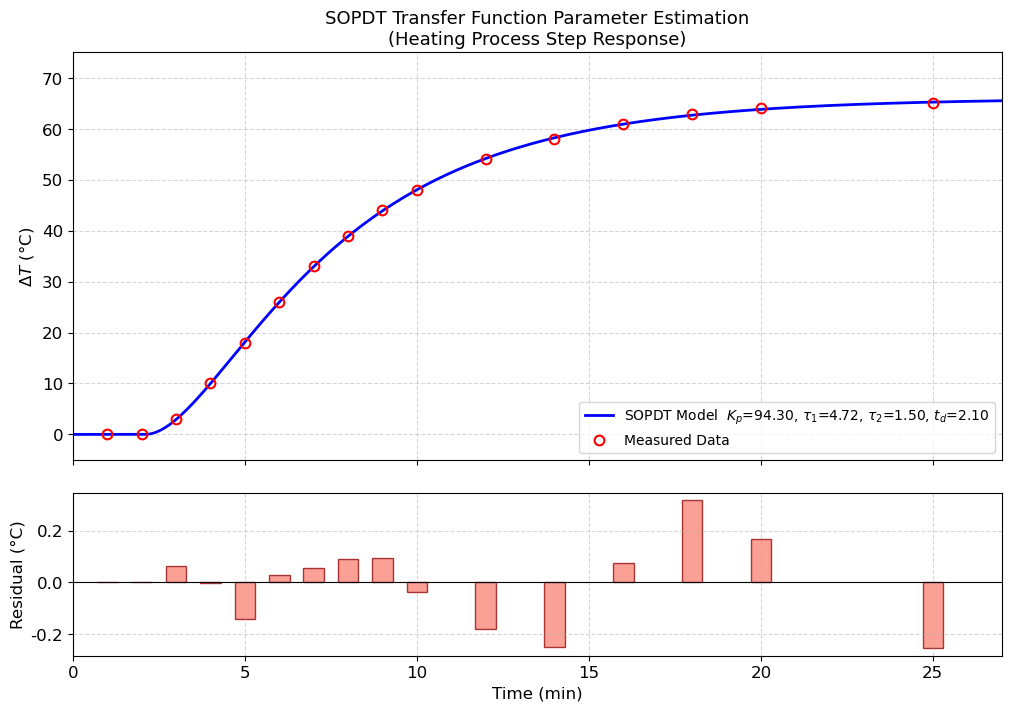

In [15]:
# ── 連續時間軸（用於繪製模型曲線）──────────────────
t_fine = np.linspace(0, 27, 500)
T_fine = sopdt_model(t_fine, *popt)

# ── 雙面板圖 ─────────────────────────────────────────
fig = plt.figure(figsize=(10, 7), constrained_layout=True)
gs  = gridspec.GridSpec(2, 1, height_ratios=[2.5, 1], hspace=0.08, figure=fig)

# --- 上圖：擬合曲線 ---
ax1 = fig.add_subplot(gs[0])
ax1.plot(t_fine, T_fine, 'b-',  linewidth=2.0,
         label=f'SOPDT Model  $K_p$={Kp_hat:.2f}, $\\tau_1$={tau1_hat:.2f}, '
               f'$\\tau_2$={tau2_hat:.2f}, $t_d$={td_hat:.2f}')
ax1.plot(t_data, T_data, 'ro',  markersize=7, markerfacecolor='none',
         markeredgewidth=1.5, label='Measured Data')
ax1.set_ylabel(r'$\Delta T$ (°C)')
ax1.set_title('SOPDT Transfer Function Parameter Estimation\n'
              '(Heating Process Step Response)')
ax1.legend(loc='lower right', fontsize=10)
ax1.set_xlim(0, 27); ax1.set_ylim(-5, 75)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.tick_params(labelbottom=False)

# --- 下圖：殘差 ---
ax2 = fig.add_subplot(gs[1], sharex=ax1)
ax2.bar(t_data, resid, color='salmon', edgecolor='darkred',
        alpha=0.75, width=0.6)
ax2.axhline(0, color='k', linewidth=0.8)
ax2.set_xlabel('Time (min)')
ax2.set_ylabel('Residual (°C)')
ax2.grid(True, linestyle='--', alpha=0.5)

# ── 儲存圖檔 ─────────────────────────────────────────
save_path = FIG_DIR / 'sopdt_fitting.png'
fig.savefig(save_path, dpi=150, bbox_inches='tight')
print(f"圖檔已儲存至：{save_path}")
plt.show()
